In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy.linalg as LA

from scipy.signal import butter, lfilter, lfilter_zi

import tensorflow as tf
from tensorflow import keras

import pandas as pd

### Setup dynamic system to generate stable and unstable trajectories

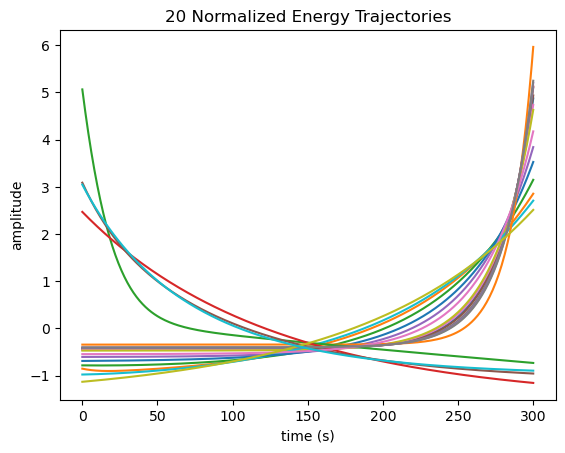

In [9]:
#Generate Filtered Normed Trajectories

#3 state linear system

def three_state(x,t,a,b):
    A = np.diag([-a,-b,-(a-b)])
    #print(A.shape)
    #print(x.shape)
    x_dot = np.dot(A,x.reshape(-1,1))
    return x_dot.squeeze()

#initial conditions
x0 = [2,4,6]  #[x1,x2,x3]

#generate time vector
num_points = 301
t = np.linspace(0,30,num_points)

#min and max parameter values
amin = -0.5
amax = 0.5
bmin = -0.5
bmax = 0.5

#number of trajectories to generate
n_traj = 5000

X = np.empty((n_traj,num_points))

params = []

for i in range(0,n_traj):
    #sample parameters uniformly
    a = np.random.uniform(amin,amax)
    b = np.random.uniform(bmin,bmax)
    
    params.append([a,b])
    
    #solve the system
    x_ = odeint(three_state, x0, t, args=(a,b))
    
    # collapse the dimension of the states with the 2 norm
    # store the normalized trajectories
    x_norm_ = LA.norm(x_,ord=2,axis=1).squeeze()
    X[i,:] = (x_norm_ - np.mean(x_norm_))/np.std(x_norm_)

# plot the normalized trajectories

num_trajectories_to_plot = 20

plt.plot(X[:num_trajectories_to_plot].transpose())
plt.title('20 Normalized Energy Trajectories')
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.show()

### Train an autoencoder to create a labeled dataset of stable/unstable trajectories

In [10]:
#split data into training, testing, and validation sets

test_idx = int(np.floor(n_traj * 0.5))
valid_idx = int(np.floor(n_traj * 0.2) + test_idx)

X_test, X_valid, X_train = X[0:test_idx], X[test_idx:valid_idx], X[valid_idx:]
param_test, param_valid, param_train = params[0:test_idx], params[test_idx:valid_idx], params[valid_idx:]

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.3829 - val_loss: 0.9944
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2020 - val_loss: 0.9821
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0925 - val_loss: 0.9670
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0011 - val_loss: 0.9431
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9275 - val_loss: 0.9278
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8865 - val_loss: 0.8776
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8336 - val_loss: 0.8196
Epoch 8/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7682 - val_loss: 0.7776
Epoch 9/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7582 - val_loss: 0.7371
Epoch 10/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7169 - val_loss: 0.6822
Epoch 11/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6732 - val_loss: 0.6367
Epoch 12/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6

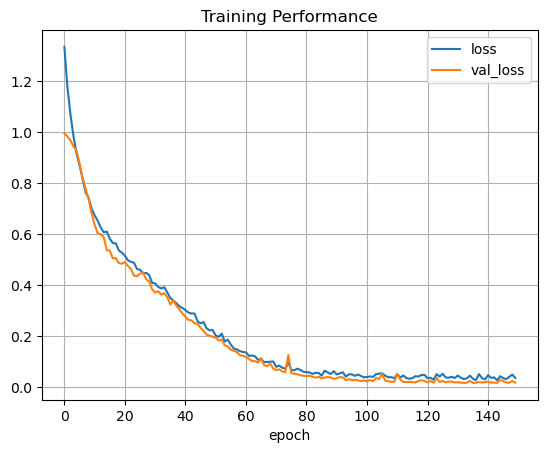

In [12]:
#build autoencoder
encoding_dim = 1
encoding_activation = 'tanh'

#encoder layers
input_encoder = keras.Input(shape=X_train[0].shape)
enc = keras.layers.Dense(100, activation='relu')(input_encoder)
enc = keras.layers.BatchNormalization()(enc)
enc = keras.layers.Dense(10, activation='relu')(enc)
enc = keras.layers.BatchNormalization()(enc)
enc = keras.layers.Dense(encoding_dim, 
                         activation=encoding_activation, 
                         activity_regularizer=keras.regularizers.l1(10e-5))(enc)

encoder = keras.Model(input_encoder,enc)
 
#decoder layers
input_decoder = keras.Input(shape=(encoding_dim,))
dec = keras.layers.BatchNormalization()(input_decoder)
dec = keras.layers.Dense(10, activation='relu')(dec)
dec = keras.layers.BatchNormalization()(dec)
dec = keras.layers.Dense(100, activation='relu')(dec)
dec = keras.layers.BatchNormalization()(dec)
dec = keras.layers.Dense(num_points)(dec)

decoder = keras.Model(input_decoder,dec)

#autoencoder
autoencoder = keras.Model(input_encoder,decoder(encoder(input_encoder)))

#compile and fit
autoencoder.compile(loss='mse', optimizer='sgd')
history = autoencoder.fit(X_train,X_train, epochs=150, validation_data=(X_valid, X_valid))

#Plot Training Results
hist_df = pd.DataFrame(history.history)
hist_df.plot()
plt.grid(True)
plt.title('Training Performance')
plt.xlabel('epoch')
plt.show()


In [13]:
#use the encoder to get encodings of the test dataset
X_pred_enc = encoder.predict(X_test)

#use the decode the encoded data (for comparison later)
X_pred_dec = decoder.predict(X_pred_enc)

#build a dataframe to store the data as csv
df = pd.DataFrame(np.concatenate((param_test, X_pred_enc),axis=1), columns=['param_0','param_1','latent_feature'])
df.head()

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,param_0,param_1,latent_feature
0,0.313958,-0.408777,-0.684673
1,0.466635,-0.122645,-0.335773
2,-0.013006,-0.156501,-0.355959
3,-0.326530,0.128389,-0.705706
4,-0.183475,0.062820,-0.510178


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


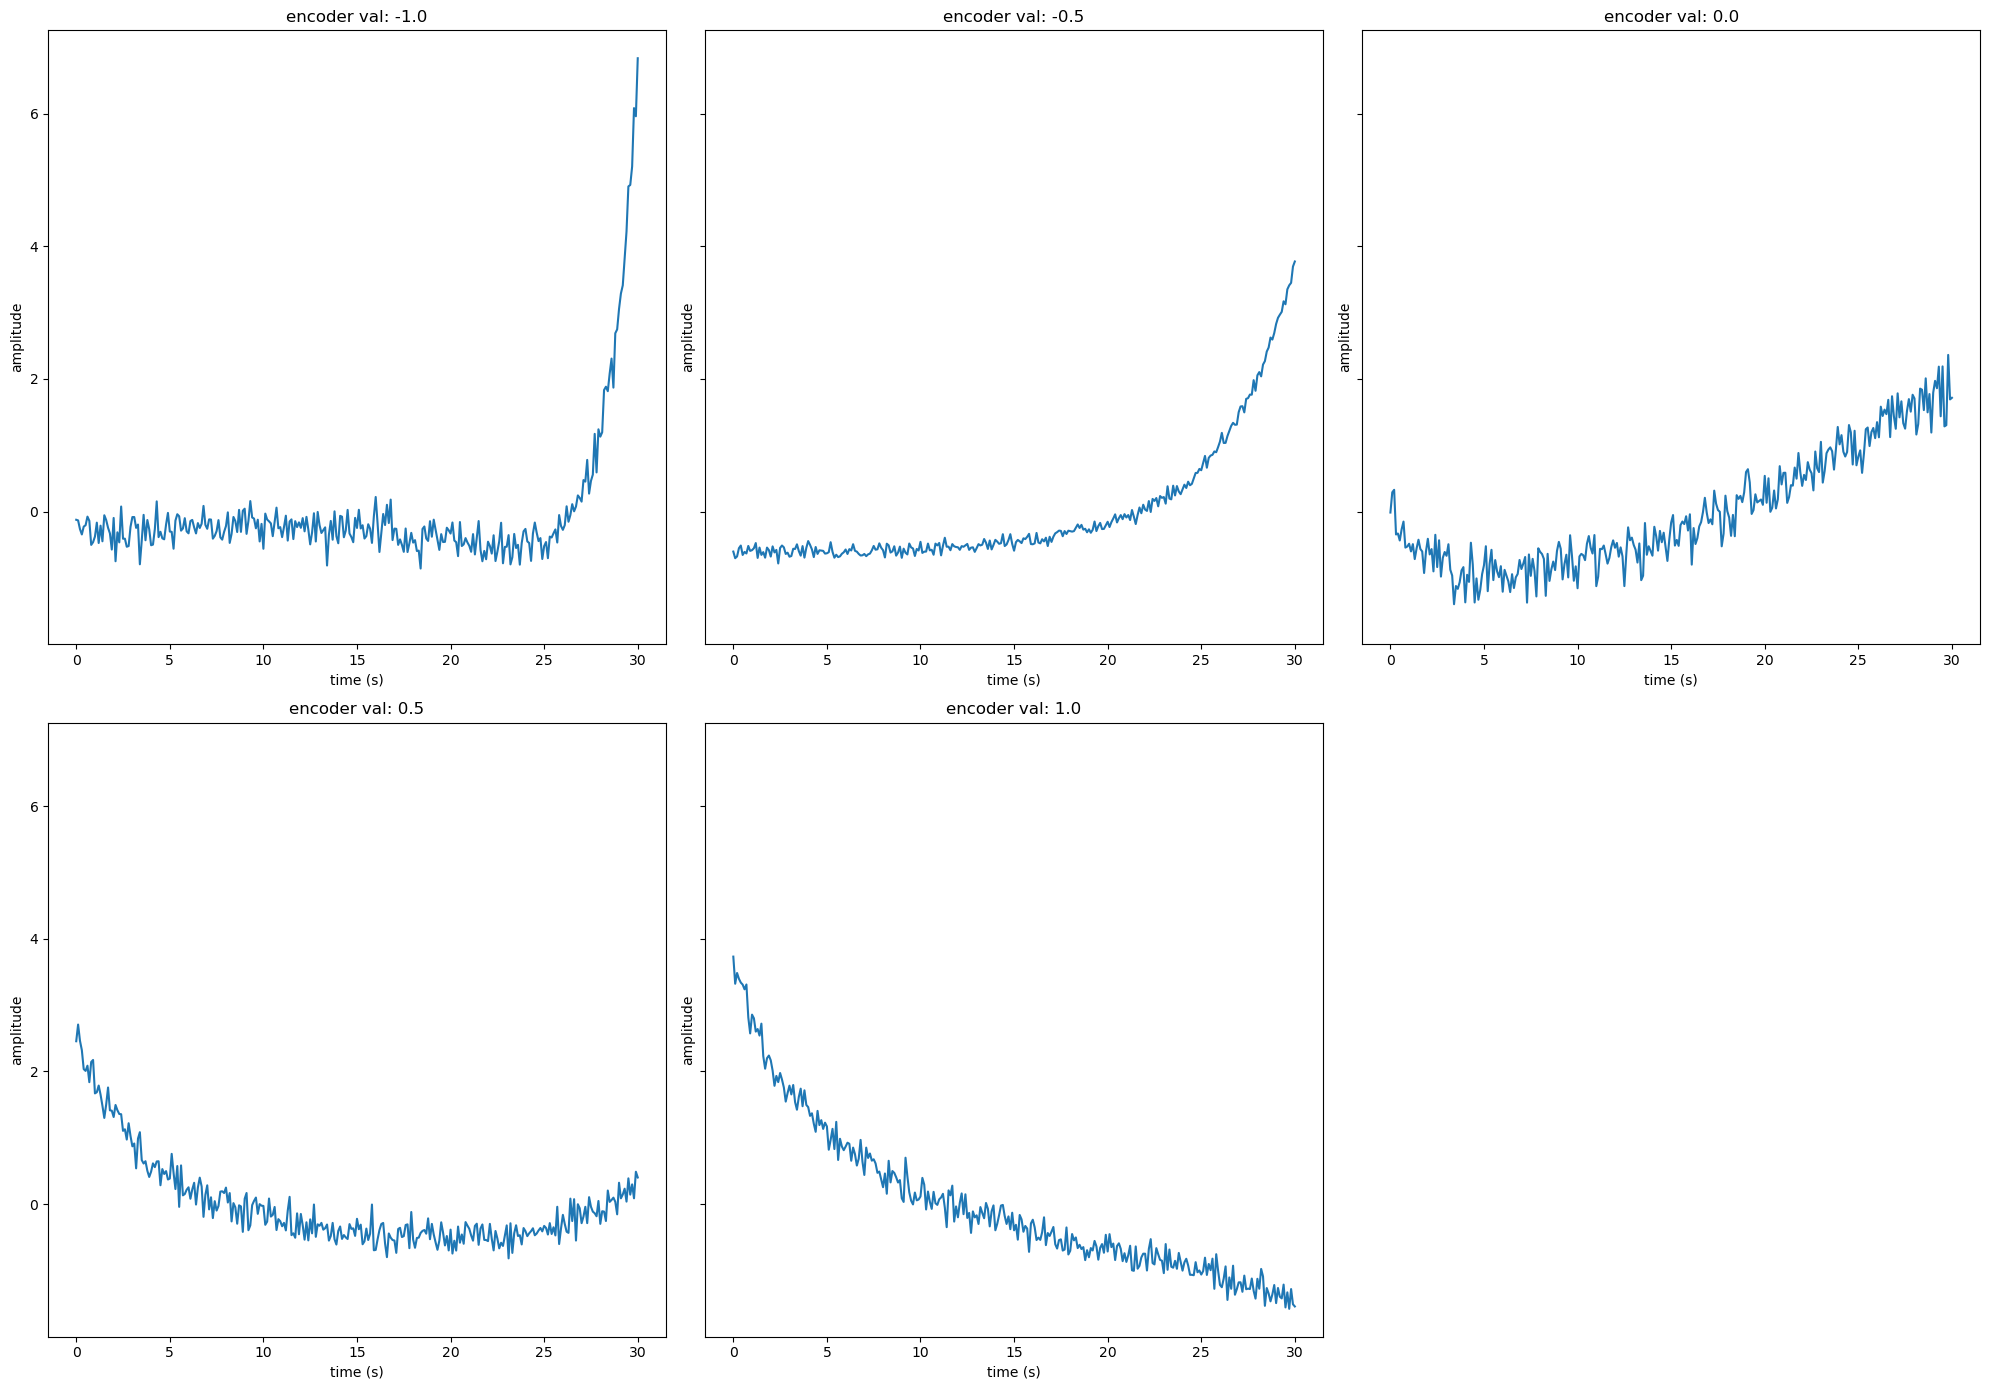

In [14]:
#Generate test encodings and decode

test_encodings = np.array([-1,-0.5, 0, 0.5, 1]).reshape(-1,1)
test_decoder = decoder.predict(tf.constant(test_encodings))

#Plot Decoded Test Encodings

num_plots = len(test_encodings)
fig, ax = plt.subplots(2, 3, sharey=True, figsize=(20,14))
ax = ax.flatten()
ax[len(ax)-1].remove()    #don't display empty axis
for i in range(0,num_plots):
    ax[i].plot(t,test_decoder[i,:])
    ax[i].set_xlabel('time (s)')
    ax[i].set_ylabel('amplitude')
    ax[i].set_title('encoder val: ' + str(test_encodings[i][0]))
    
fig.tight_layout()

#Save figure (if needed)
plt.savefig('Decoded_test_encodings.png')

plt.show()

Encoder value:  [0.79746157]
Parameters that generated the test data:  [0.3754157197465492, 0.07706219775979262]


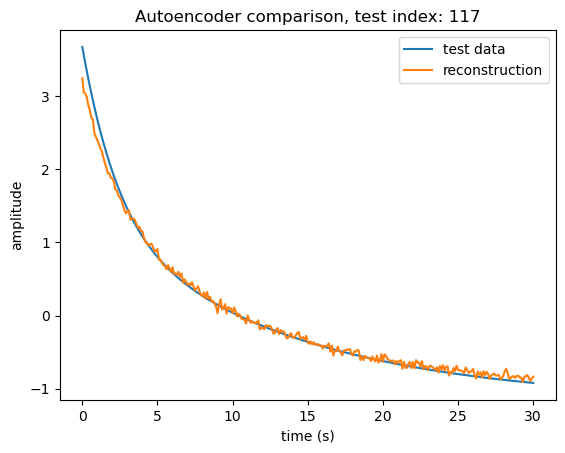

In [19]:
#Compare AutoEncoder to Test Data

idx = 117   #index of test data to plot
print("Encoder value: ", X_pred_enc[idx])
print("Parameters that generated the test data: ", param_test[idx])
plt.plot(t,X_test[idx], label='test data')
plt.plot(t,X_pred_dec[idx], label='reconstruction')
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.title('Autoencoder comparison, test index: ' + str(idx))
plt.legend()
plt.show()